<a href="https://colab.research.google.com/github/teejay541/HOUSE-PRICE-PREDICTION/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HOUSE PRICE PREDICTION



# LOAD DATA

In [ ]:
#Import Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

In [ ]:
df = pd.read_csv('/content/House_Price_Prediction_Dataset_a2sttc.csv')
print("Dataset loaded successfully. Displaying the first 5 rows:")
display(df.head())

Dataset loaded successfully. Displaying the first 5 rows:


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


### 1. Dataset Information

In [ ]:

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB
None


### 2. Descriptive Statistics

In [ ]:
# Display descriptive statistics for numerical columns
display(df.describe())

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


### 3. Missing Values Analysis

,Missing Count,Missing Percentage


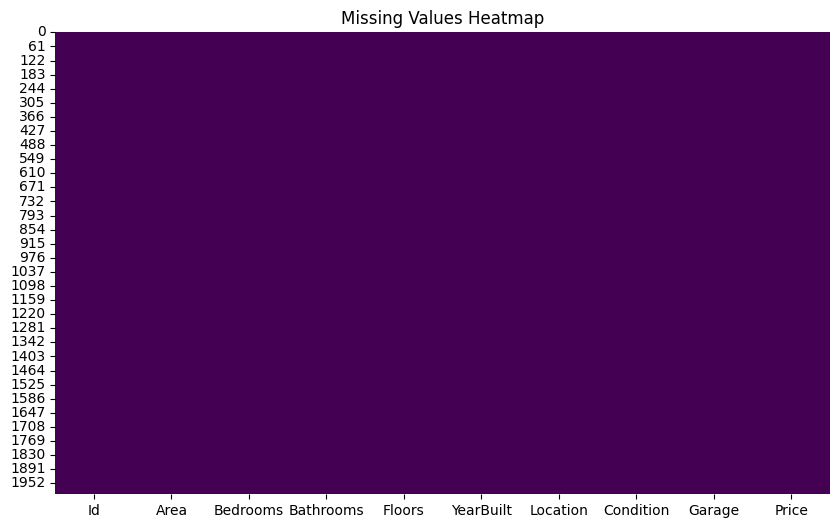

In [ ]:
# Calculate and display the percentage of missing values for each column
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage})

# Filter to show only columns with missing values and sort them
display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False))

# Visualize missing values (optional, for larger datasets this helps to see patterns)
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

### 4. Distribution of the Target Variable (SalePrice)

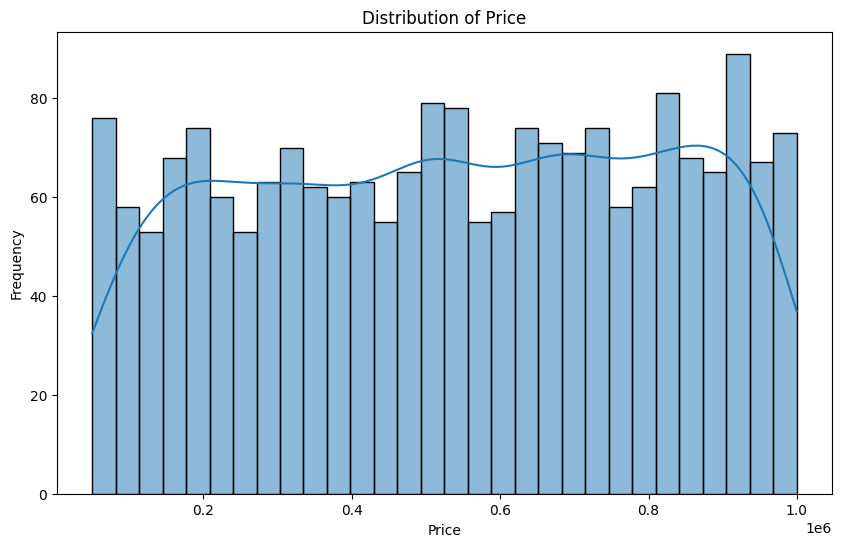

In [ ]:
# Plot the distribution of 'SalePrice' using a histogram and a KDe plot
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True, bins=30)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

### 5. Correlation Matrix of Numerical Features

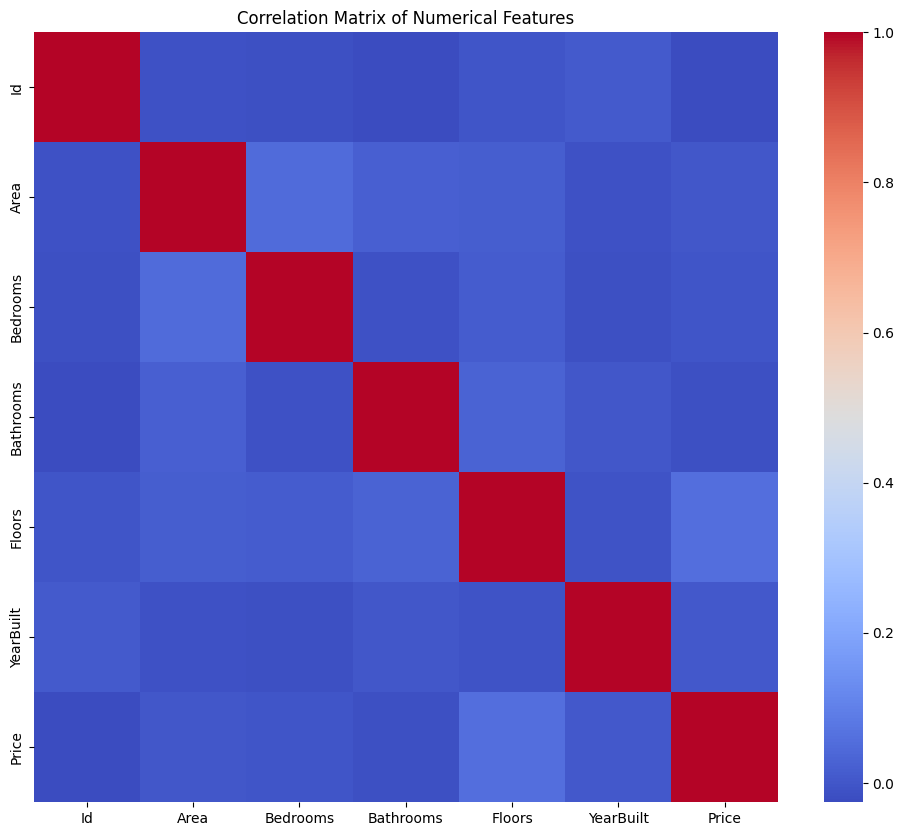

In [ ]:
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### 6. Analyze Categorical Features

Found 3 categorical columns: ['Location', 'Condition', 'Garage']

--- Column: Location ---
Location
Downtown    558
Urban       485
Suburban    483
Rural       474
Name: count, dtype: int64


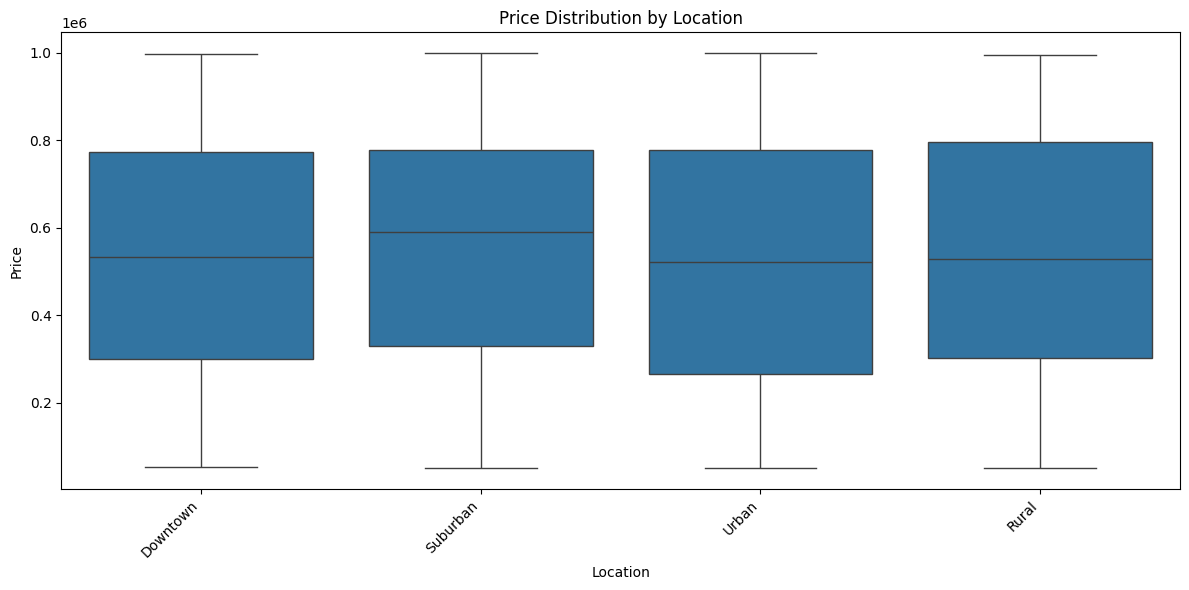


--- Column: Condition ---
Condition
Fair         521
Excellent    511
Poor         507
Good         461
Name: count, dtype: int64


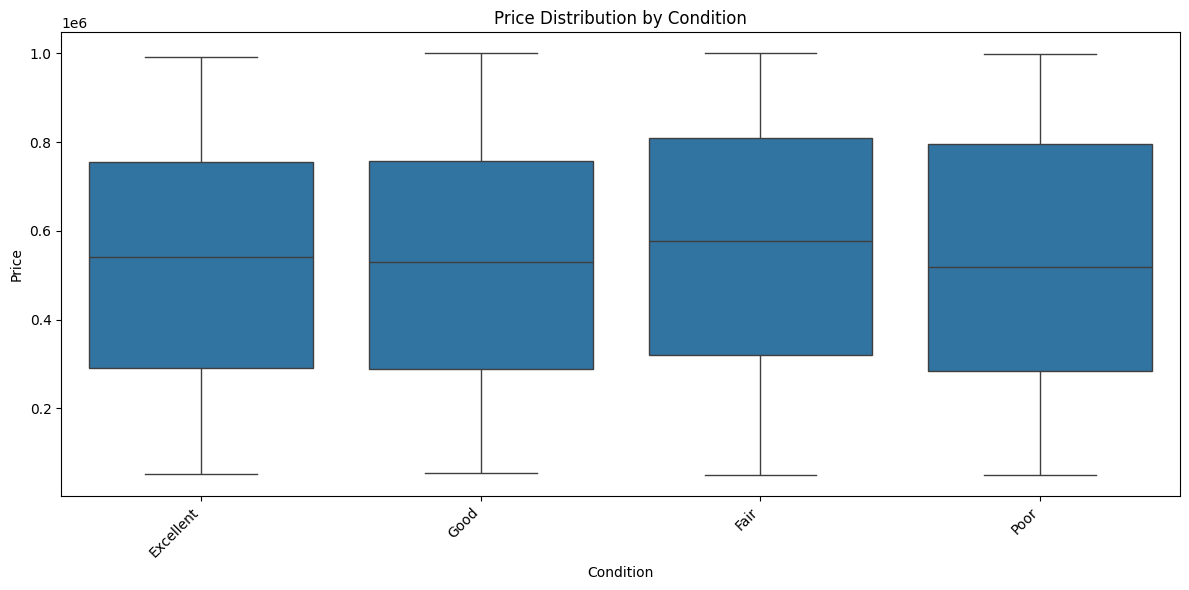


--- Column: Garage ---
Garage
No     1038
Yes     962
Name: count, dtype: int64


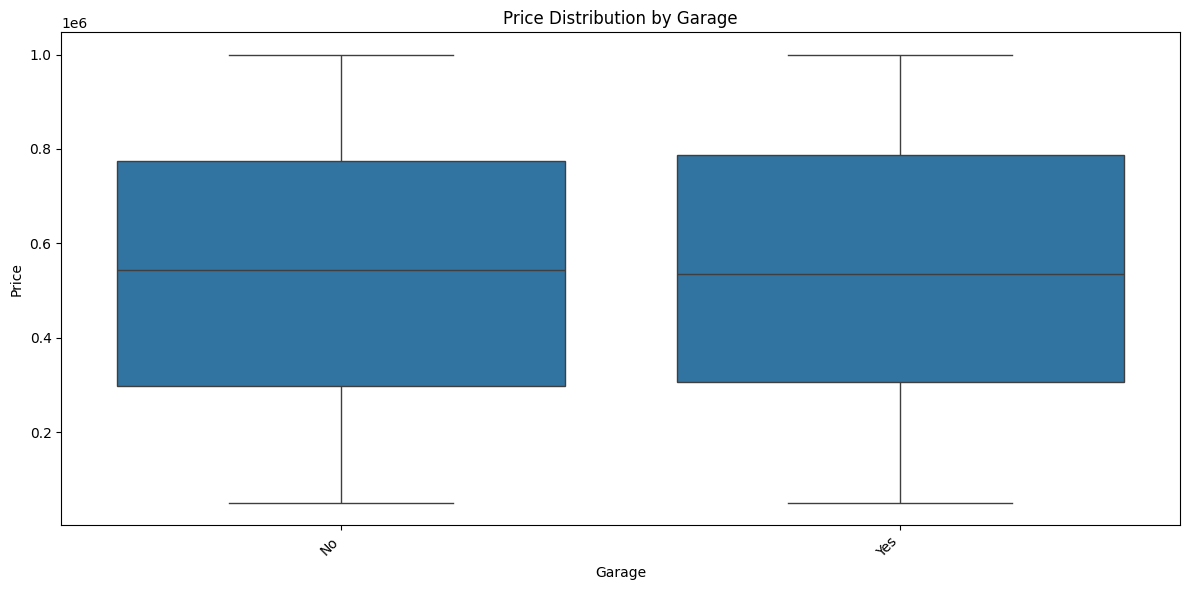

In [ ]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

print(f"Found {len(categorical_cols)} categorical columns: {list(categorical_cols)}")

# For each categorical column, display unique values and value counts
for col in categorical_cols:
    print(f"\n--- Column: {col} ---")
    print(df[col].value_counts())

    # Plot distribution against Price if there are not too many unique values
    if df[col].nunique() < 20:
        plt.figure(figsize=(12, 6))
        sns.boxplot(x=col, y='Price', data=df)
        plt.title(f'Price Distribution by {col}')
        plt.xlabel(col)
        plt.ylabel('Price')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

### 7. Visualize Key Numerical Features vs. Price

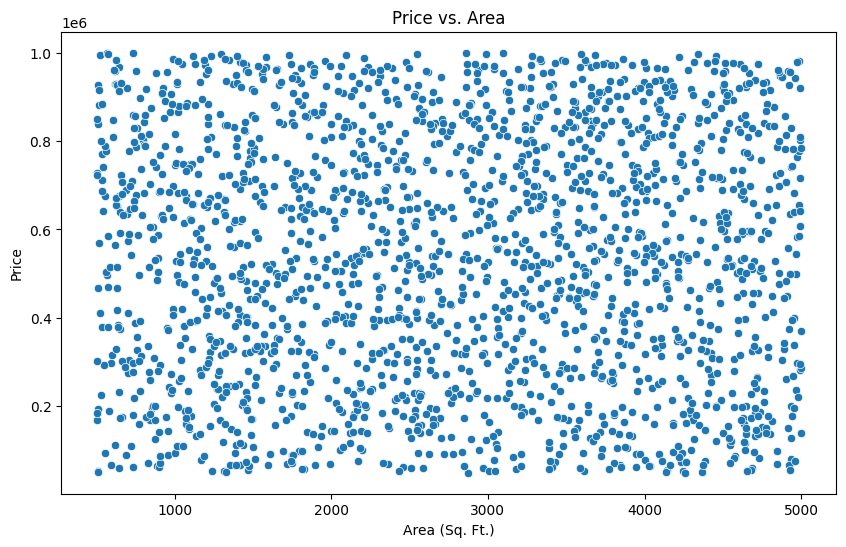

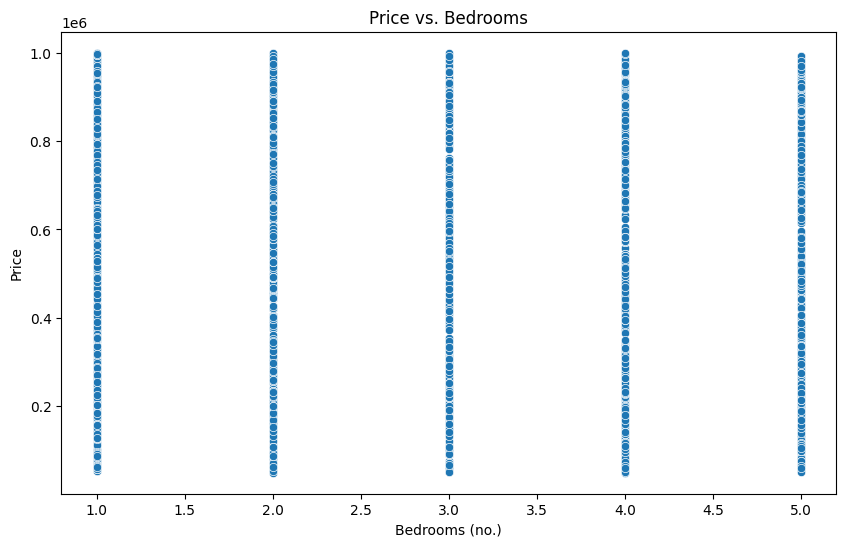

In [ ]:
# Example: Relationship between 'Area' (Above grade (ground) living area square feet) and 'Price'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Area', y='Price', data=df)
plt.title('Price vs. Area')
plt.xlabel('Area (Sq. Ft.)')
plt.ylabel('Price')
plt.show()

# Example: Relationship between 'Bedrooms' and 'Price'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Bedrooms', y='Price', data=df)
plt.title('Price vs. Bedrooms')
plt.xlabel('Bedrooms (no.)')
plt.ylabel('Price')
plt.show()

### 8. Outlier Detection in Key Numerical Features

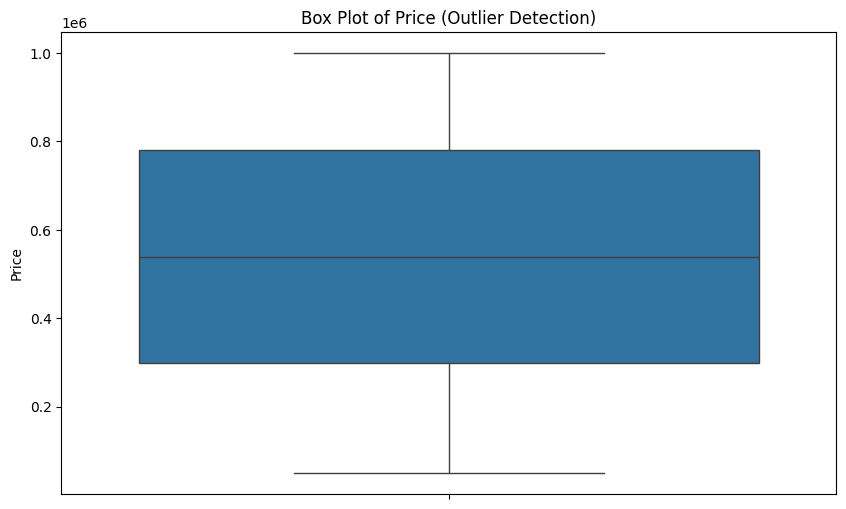

In [ ]:
# Box plot for 'Price' to visualize outliers
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Price'])
plt.title('Box Plot of Price (Outlier Detection)')
plt.ylabel('Price')
plt.show()


### 9. Feature Engineering: Encoding Categorical Features

In [ ]:
# Identify categorical columns to be encoded
categorical_cols = ['Location', 'Condition', 'Garage']

# Apply One-Hot Encoding using pandas get_dummies
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame after One-Hot Encoding:")
display(df_encoded.head())

print(f"Original DataFrame shape: {df.shape}")
print(f"Encoded DataFrame shape: {df_encoded.shape}")